<a href="https://colab.research.google.com/github/diogenesjusto/FIAP/blob/master/MBAIA/17DTSR/17DTR_Aula4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 17DTSR - AULA 4 - Parte 1, Séries Temporais - rollins statistics, null's

In [3]:

import pandas as pd
import numpy as np
import matplotlib as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [33]:
df = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/master/SHIFT/Data/pib.csv')

In [8]:
# Estatísticas em janelas (ou rolling statistics)
df['PIB_mm_3'] = df['PIB'].rolling(window=3).mean()
df['PIB_mm_6'] = df['PIB'].rolling(window=6).mean()
df

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12,PIB_mm_3,PIB_mm_6
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00,NaN,NaN
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,NaN,NaN
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,105.190000,NaN
3,4,abr/04,106.77,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,106.416667,NaN
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,108.426667,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.92,148.210000,151.130000
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.536667,150.736667
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,147.710000,149.133333
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,149.216667,148.713333


# Tratamento de Nulos para Séries Temporais

Problema: em Séries Temporais eliminar uma "linha" não é uma possibilidade por causa das sazonalidades

In [11]:
# Valores nulos:
df.at[ 3, 'PIB'] = np.nan
df

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12,PIB_mm_3,PIB_mm_6
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00,NaN,NaN
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,NaN,NaN
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,105.190000,NaN
3,4,abr/04,NaN,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,106.416667,NaN
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,108.426667,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.92,148.210000,151.130000
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.536667,150.736667
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,147.710000,149.133333
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,149.216667,148.713333


In [13]:
# Solução 1: Preencher com o anterior ou posterior
df['PIBt'] = df['PIB'].fillna(method='bfill')
df

/tmp/ipykernel_6320/4125659119.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['PIBt'] = df['PIB'].fillna(method='bfill')


,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12,PIB_mm_3,PIB_mm_6,PIBt
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,102.24,99.96,101.93,101.17,101.70,100.03,100.00,NaN,NaN,103.09
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,102.59,102.24,99.96,101.93,101.17,101.70,100.03,NaN,NaN,102.05
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,104.52,102.59,102.24,99.96,101.93,101.17,101.70,105.190000,NaN,110.43
3,4,abr/04,NaN,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,106.416667,NaN,108.08
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,108.426667,NaN,108.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,154.75,154.34,148.92,154.49,150.92,151.44,148.92,148.210000,151.130000,144.42
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.536667,150.736667,151.68
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,156.65,154.04,154.75,154.34,148.92,154.49,150.92,147.710000,149.133333,147.03
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,149.216667,148.713333,148.94


In [14]:
# Solução 2: Cálculos de interpolações com diversas técnicas, linear, etc, para ajustes mais precisos a geomtria da série temporal
df['PIBt2'] = df['PIB'].interpolate()
df

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12,PIB_mm_3,PIB_mm_6,PIBt,PIBt2
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,99.96,101.93,101.17,101.70,100.03,100.00,NaN,NaN,103.09,103.090
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,102.24,99.96,101.93,101.17,101.70,100.03,NaN,NaN,102.05,102.050
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,102.59,102.24,99.96,101.93,101.17,101.70,105.190000,NaN,110.43,110.430
3,4,abr/04,NaN,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,104.52,102.59,102.24,99.96,101.93,101.17,106.416667,NaN,108.08,109.255
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,106.27,104.52,102.59,102.24,99.96,101.93,108.426667,NaN,108.08,108.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,154.34,148.92,154.49,150.92,151.44,148.92,148.210000,151.130000,144.42,144.420
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,154.75,154.34,148.92,154.49,150.92,151.44,148.536667,150.736667,151.68,151.680
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,154.04,154.75,154.34,148.92,154.49,150.92,147.710000,149.133333,147.03,147.030
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,156.65,154.04,154.75,154.34,148.92,154.49,149.216667,148.713333,148.94,148.940


# Parte 2 - Discretização

In [15]:
dfCred = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/refs/heads/master/dados/credit_features_formatado.csv')

/tmp/ipykernel_6320/370353546.py:1: DtypeWarning: Columns (52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  dfCred = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/refs/heads/master/dados/credit_features_formatado.csv')


<Axes: >

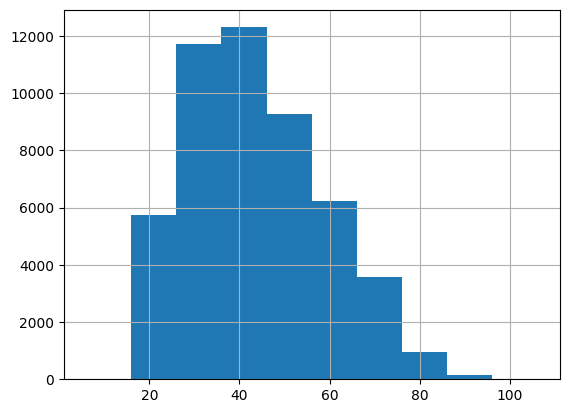

In [17]:
dfCred['IDADE'].hist()

Solução 1: largura fixa de intervalos

In [18]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 11.0 MB/s eta 0:00:00


In [19]:
# Sugestão/dica: explorem a biblioteca feature_engine pois tem muitas ferramentas para F.Eng.
from feature_engine.discretisation import EqualWidthDiscretiser

In [23]:
# passo 1: cria a função específica
discEW = EqualWidthDiscretiser(bins=5, variables='IDADE')
# passo 2: aplica a função
discEW.fit(dfCred)
dfCredT = discEW.transform(dfCred)
dfCredT.groupby('IDADE').count()

,Unnamed: 0,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,...,NIVEL_EDUCACIONAL_CONJUGE,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU=1
IDADE,,,,,,,,,,,,,,,,,,,,,
0,6763,6763,6763,6763,6763,6763,6763,6763,6763,6763,...,2182,6763,6763,6763,6763,6763,6763,6763,6763,6763
1,24106,24106,24106,24106,24106,24106,24106,24106,24106,24106,...,8596,24106,24106,24106,24106,24106,24106,24106,24106,24106
2,15029,15029,15029,15029,15029,15029,15029,15029,15029,15029,...,5358,15029,15029,15029,15029,15029,15029,15029,15029,15029
3,3977,3977,3977,3977,3977,3977,3977,3977,3977,3977,...,1479,3977,3977,3977,3977,3977,3977,3977,3977,3977
4,125,125,125,125,125,125,125,125,125,125,...,47,125,125,125,125,125,125,125,125,125


In [ ]:
Solução 2: largura variável de intervalos, com mesma quantidade elementos ou objetos dentro de cada Intervalo

In [29]:
from sklearn.preprocessing import KBinsDiscretizer

discKB = KBinsDiscretizer(n_bins=5,encode='ordinal', strategy='quantile')
dfCredT2 = discKB.fit_transform(dfCred[['IDADE']])

dfCred['PIB_DiscKB'] = dfCredT2

dfCred.groupby('PIB_DiscKB').count()

,Unnamed: 0,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU=1
PIB_DiscKB,,,,,,,,,,,,,,,,,,,,,
0.0,9055,9055,9055,9055,9055,9055,9055,9055,9055,9055,...,9055,9055,9055,9055,9055,9055,9055,9055,9055,9055
1.0,9706,9706,9706,9706,9706,9706,9706,9706,9706,9706,...,9706,9706,9706,9706,9706,9706,9706,9706,9706,9706
2.0,11019,11019,11019,11019,11019,11019,11019,11019,11019,11019,...,11019,11019,11019,11019,11019,11019,11019,11019,11019,11019
3.0,10095,10095,10095,10095,10095,10095,10095,10095,10095,10095,...,10095,10095,10095,10095,10095,10095,10095,10095,10095,10095
4.0,10125,10125,10125,10125,10125,10125,10125,10125,10125,10125,...,10125,10125,10125,10125,10125,10125,10125,10125,10125,10125


# Parte 3 - Feature Importance




In [34]:
# 1a Técnica: análise da magnitude dos coeficientes
# Analisaremos sobre os dados do pib
df

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi3,PIBi4,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70
3,4,abr/04,106.77,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,103.09,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,102.05,103.09,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.92
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,149.51,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,144.42,149.51,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49


In [48]:
# Separação Treino e Teste
# Dados temporais (série temporal): amostragem por janela temporal
treino = df.iloc[0:126]
teste = df.iloc[126:]

X = ['SLP', 'SPP', 'RJL', 'RJP'] # Modelo Multi-variado, onde Y é o PIB, e X são dados de tráfego - ref. ABCR.org

X_treino = treino.loc[:,X]
Y_treino = treino.iloc[:,2]

mod = LinearRegression()
mod.fit(X_treino, Y_treino)



LinearRegression()

In [65]:
# Analisando as estatísticas do modelo de regressão linear
mod.coef_

array([ 0.47091547,  0.43530889, -0.31786917,  0.00223493])

In [51]:
# 2a Técnica: utilização RandomForest
from sklearn.ensemble import RandomForestRegressor

modRF = RandomForestRegressor()
modRF.fit(X_treino, Y_treino)

modRF.feature_importances_

array([0.0528962 , 0.58605054, 0.01728052, 0.34377274])

<Axes: >

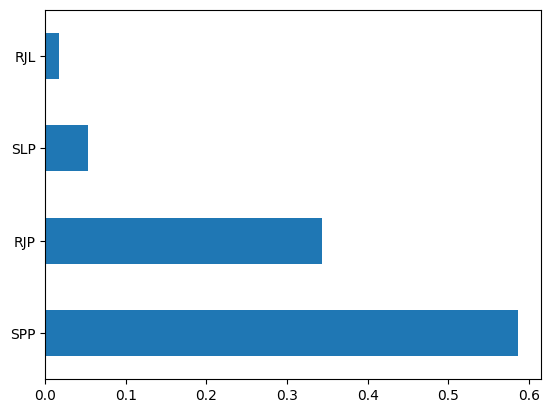

In [54]:
# Visualização gráfica de importância de variáveis
feature_importance = pd.Series(modRF.feature_importances_, index=modRF.feature_names_in_)
feature_importance.nlargest(6).plot(kind='barh')

In [58]:
# 3a Técnica: permutação: a técnica de permutação é a que se utiliza de dados de treino e teste, ou seja, estima importância baseada no resultado do modelo efetivamente
from sklearn.inspection import permutation_importance


<BarContainer object of 4 artists>

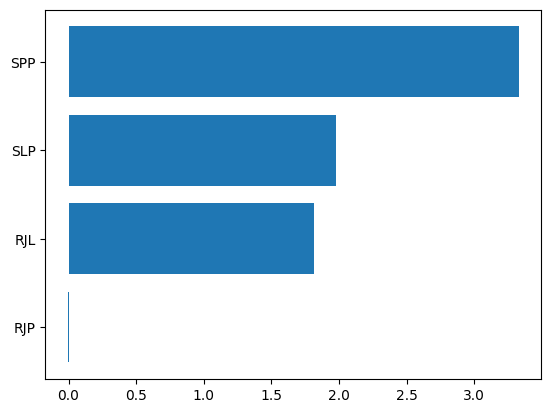

In [64]:
X_teste = teste.loc[:,X]
Y_teste = teste.iloc[:,2]

# Método é agnóstico ao modelo (técnica/algoritmo + variáveis), baseado no objeto mod escolhido
perm_importance = permutation_importance(mod, X_teste, Y_teste, n_repeats=200)

# Visualização gráfica
ordem_idx = perm_importance.importances_mean.argsort()
plt.pyplot.barh(X_teste.columns[ordem_idx], perm_importance.importances_mean[ordem_idx])

<BarContainer object of 4 artists>

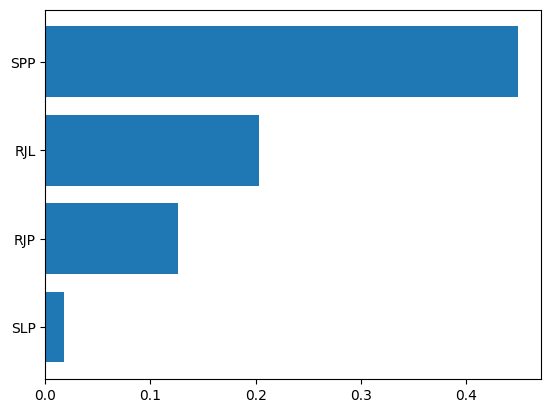

In [66]:
# Método é agnóstico ao modelo (técnica/algoritmo + variáveis), baseado no objeto mod escolhido
perm_importance = permutation_importance(modRF, X_teste, Y_teste, n_repeats=200)

# Visualização gráfica
ordem_idx = perm_importance.importances_mean.argsort()
plt.pyplot.barh(X_teste.columns[ordem_idx], perm_importance.importances_mean[ordem_idx])

# Parte 4 - Feature Engineering com AutoML


In [67]:
# Vamos explorar o pyCaret
!pip install --pre pyCaret

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.8/831.8 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.39.0 which is incompatible.


In [4]:
# Carga da biblioteca pyCaret
from pycaret.classification import *
dfT = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/train.csv')

In [6]:
# Construção do treino, teste, feature eng. e transformações
exp = ClassificationExperiment(target='Survived').fit(dfT)

In [8]:
# Análise das features
print(exp.get_config('X_train_transformed'))

     PassengerId  Pclass        Age  SibSp  Parch     Fare   Name  Sex  \
231        232.0     3.0  29.000000    0.0    0.0   7.7750  308.0  1.0   
836        837.0     3.0  21.000000    0.0    0.0   8.6625  435.0  1.0   
639        640.0     3.0  29.526048    1.0    0.0  16.1000  563.0  1.0   
389        390.0     2.0  17.000000    0.0    0.0  12.0000  316.0  0.0   
597        598.0     3.0  49.000000    0.0    0.0   0.0000  277.0  1.0   
..           ...     ...        ...    ...    ...      ...    ...  ...   
131        132.0     3.0  20.000000    0.0    0.0   7.0500  110.0  1.0   
490        491.0     3.0  29.526048    1.0    0.0  19.9667  215.0  1.0   
838        839.0     3.0  32.000000    0.0    0.0  56.4958  107.0  1.0   
48          49.0     3.0  29.526048    2.0    0.0  21.6792  501.0  1.0   
80          81.0     3.0  22.000000    0.0    0.0   9.0000  587.0  1.0   

     Ticket  Cabin  Embarked  
231   240.0   32.0       2.0  
836   201.0   32.0       2.0  
639   344.0   32.0

In [10]:
# Geração e comparação de vários algoritmos
top = exp.compare_models()


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Info] Number of positive: 215, number of negative: 345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 783
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383929 -> initscore=-0.472906
[LightGBM] [Info] Start training from score -0.472906
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.p

In [11]:
print(top.leaderboard)

       Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
0         rf    0.8379  0.8836  0.7232  0.8393  0.7711  0.6474  0.6568
1         et    0.8220  0.8729  0.7109  0.8085  0.7521  0.6148  0.6220
2        gbc    0.8220  0.8738  0.7274  0.7918  0.7558  0.6165  0.6200
3    xgboost    0.8172  0.8684  0.7315  0.7798  0.7521  0.6079  0.6112
4   lightgbm    0.8123  0.8717  0.7150  0.7806  0.7426  0.5959  0.6006
5        ada    0.7948  0.8503  0.7025  0.7501  0.7227  0.5604  0.5635
6        qda    0.7899  0.8373  0.7029  0.7429  0.7165  0.5507  0.5570
7         lr    0.7884  0.8469  0.6946  0.7365  0.7122  0.5456  0.5485
8      ridge    0.7820  0.0000  0.6951  0.7256  0.7088  0.5350  0.5363
9        lda    0.7820  0.8477  0.6951  0.7256  0.7088  0.5350  0.5363
10        nb    0.7640  0.8207  0.6442  0.7198  0.6745  0.4912  0.4978
11        dt    0.7527  0.7383  0.6775  0.6839  0.6761  0.4768  0.4808
12       svm    0.6422  0.0000  0.5013  0.6001  0.5080  0.2428  0.2616
13    